In [329]:
import json

import numpy as np
import pandas as pd

import seaborn as sns

from matplotlib import pyplot as plt


In [330]:
non_dataset_exercises = ["Ab Crunch Machine","Leg Raises",
"Side Crunches",
"Ab Roll Outs",
"Preacher Curls",
"Back Extensions",
"Pull-ups",
"Chest Fly Machine",
"Chest Press Machine",
"Cable Chest Fly",
"Bulgarian Split Squat",
"Romanian Deadlifts",
"Stiff-Leg Deadlifts",
"Machine Deadlifts",
"Single Leg Romanian Deadlifts",]

In [331]:
EXERCISE_GROUPS = {
    "Ab Crunch Machine":        "Abs",
    "Crunches":                 "Abs",
    "Leg Raises":               "Abs",
    "Plank":                    "Abs",
    "Side Crunches":            "Abs",
    "Ab Roll Outs":             "Abs",

    "Dumbbell Bicep Curls":     "Biceps",
    "Hammer Curls":             "Biceps",
    "Incline Dumbbell Curls":   "Biceps",
    "Preacher Curls":           "Biceps",
    "Tricep Pushdowns":         "Triceps",
    "Cable Overhead Extensions": "Triceps",
    "Dips":                     "Triceps",

    "Cable Rows":               "Back",
    "Lat Pulldowns":            "Back",
    "Row Machine":              "Back",
    "Straight Arm Lat Pulldowns": "Back",
    "Back Extensions":          "Back",
    "Pull-ups":                 "Back",

    "Bench Press":              "Chest",
    "Chest Fly Machine":        "Chest",
    "Chest Press Machine":      "Chest",
    "Dumbbell Bench Press":     "Chest",
    "Dumbell Chest Flys":       "Chest",
    "Cable Chest Fly":          "Chest",
    "Incline Dumbbell Bench Press": "Chest",

    "Barbell Squats":           "Legs",
    "Bulgarian Split Squat":    "Legs",
    "Goblet Squats":            "Legs",
    "Lunges":                   "Legs",
    "Romanian Deadlifts":       "Legs",
    "Stiff-Leg Deadlifts":      "Legs",
    "Treadmill Running":        "Legs",
    "Machine Deadlifts":        "Legs",
    "Single Leg Romanian Deadlifts": "Legs",

    "Dumbbell Lateral Raises":  "Shoulders",
    "Dumbbell Overhead Press":  "Shoulders",
    "Machine Lateral Raises":   "Shoulders",
    "Cable Lateral Raises":     "Shoulders",

}

GROUP_ORDER = ["Abs", "Biceps", "Triceps", "Back", "Chest", "Legs", "Shoulders"]

# Load methods

In [332]:
def load_sessions(session_paths, ignore_list=None):
    ignore_list = ignore_list or []

    all_session_windows = []
    all_session_events = []

    session_id = 1

    for path in session_paths:
        accel, gyro, clf, annotations, info = load_recording(path)

        events_watch_time = convert_events_to_watch_time(
            annotations,
            info
        )

        clf, events = remove_ignored_exercises(
            clf,
            events_watch_time,
            ignore_list=ignore_list
        )

        for event in events:
            event["group"] = EXERCISE_GROUPS.get(event["name"], "Unknown")
            event["session"] = path
            event["session_id"] = session_id

        clf = add_ground_truth(clf, events)
        clf["session"] = path
        clf["session_id"] = session_id

        session_id += 1

        all_session_windows.append(clf)
        all_session_events.extend(events)

    return all_session_windows, all_session_events

def load_recording(path):
    accel = pd.read_csv(f"{path}/accel.csv")
    gyro = pd.read_csv(f"{path}/gyro.csv")
    classification = pd.read_csv(f"{path}/classification.csv")

    with open(f"{path}/annotations.json") as f:
        annotations = json.load(f)

    with open(f"{path}/info.txt") as f:
        lines = f.read().splitlines()

    info = {
        "watch_start_timestamp": int(lines[0].split("=")[1]),
        "watch_end_timestamp": int(lines[2].split("=")[1]),
    }

    return accel, gyro, classification, annotations, info

def convert_events_to_watch_time(annotations, info, linear=False):
    phone_start = annotations["phoneStartTimestamp"]
    phone_end = annotations["phoneEndTimestamp"]

    watch_start = info["watch_start_timestamp"]
    watch_end = info["watch_end_timestamp"]

    events_watch = []

    if linear:
        a = (watch_end - watch_start) / (phone_end - phone_start)
        b = watch_start - a * phone_start

        for event in annotations["events"]:
            start_watch = a * event["startTime"] + b
            end_watch = a * event["endTime"] + b

            events_watch.append({
                "name": event["name"],
                "start_watch": start_watch,
                "end_watch": end_watch
            })

    else:
        offset = phone_start - watch_start

        for event in annotations["events"]:
            events_watch.append({
                "name": event["name"],
                "start_watch": event["startTime"] - offset,
                "end_watch": event["endTime"] - offset
            })

    events_watch.sort(key=lambda x: x["start_watch"])
    return events_watch

def remove_ignored_exercises(clf, events, ignore_list, ignore_buffer_ms=20_000):
    df = clf.copy()

    filtered_events = [e for e in events if e["name"] not in ignore_list]
    ignored_events = [e for e in events if e["name"] in ignore_list]

    for event in ignored_events:
        start = event["start_watch"] - ignore_buffer_ms
        end = event["end_watch"] + ignore_buffer_ms

        df = df[
            (df["timestamp"] < start) |
            (df["timestamp"] > end)
        ]

    return df, filtered_events

def add_ground_truth(df, events):
    df = df.copy()

    df["ground_truth"] = 0
    df["ground_truth_activity"] = "Rest"
    df["ground_truth_group"] = "Rest"

    for event in events:
        mask = (
            (df["timestamp"] >= event["start_watch"]) &
            (df["timestamp"] <= event["end_watch"])
        )

        df.loc[mask, "ground_truth"] = 1
        df.loc[mask, "ground_truth_activity"] = event["name"]
        df.loc[mask, "ground_truth_group"] = event["group"]

    return df

# Load sessions

In [333]:
session_paths = [
    "session_1776786984700",
    "session_1776875240569",
    "session_1776938763711",
    "session_1777025558126",
    "session_1777104300830",
    "session_1777394359098",
    "session_1777462103399"
]

session_windows, all_events = load_sessions(
    session_paths,
    ignore_list=[]
)

windows_df = pd.concat(session_windows, ignore_index=True)
events_df = pd.DataFrame(all_events)

In [334]:
events_df

,name,start_watch,end_watch,group,session,session_id
0,Goblet Squats,1776787245500,1776787285953,Legs,session_1776786984700,1
1,Goblet Squats,1776787419901,1776787442407,Legs,session_1776786984700,1
2,Dumbbell Bicep Curls,1776787568132,1776787595361,Biceps,session_1776786984700,1
3,Dumbbell Bicep Curls,1776787643532,1776787669601,Biceps,session_1776786984700,1
4,Dumbbell Bicep Curls,1776787734931,1776787755462,Biceps,session_1776786984700,1
...,...,...,...,...,...,...
135,Dumbbell Overhead Press,1777466816373,1777466836962,Shoulders,session_1777462103399,7
136,Dumbbell Overhead Press,1777466999503,1777467023680,Shoulders,session_1777462103399,7
137,Leg Raises,1777467487399,1777467512637,Abs,session_1777462103399,7
138,Leg Raises,1777468015678,1777468034084,Abs,session_1777462103399,7


In [335]:
from sklearn.metrics import classification_report


print(classification_report(windows_df["ground_truth"], windows_df["prediction_binary"]))

              precision    recall  f1-score   support

           0       0.93      0.92      0.93     29215
           1       0.56      0.61      0.58      4887

    accuracy                           0.87     34102
   macro avg       0.74      0.76      0.75     34102
weighted avg       0.88      0.87      0.88     34102



# Stability/ segment analysis

## Fragmentation

In [336]:
def plot_fragmentation_distribution(fragmentation_df):
    f, ax = plt.subplots(figsize=(7, 4))

    sns.countplot(
        data=fragmentation_df,
        x="extra_fragments",
        color="skyblue"
    )

    ax.set(
        xlabel="Fragmentāciju skaits",
        ylabel="Segmentu skaits",
        #title="Vingrošanas segmentu fragmentācija"
    )

    ax.xaxis.grid(True)

    sns.despine()

    plt.show()

def plot_fragmentation_per_exercise(fragmentation_df):
    f, ax = plt.subplots(figsize=(8, max(3, fragmentation_df["name"].nunique() * 0.3)))

    sns.boxplot(
        data=fragmentation_df,
        x="extra_fragments",
        y="name",
        color="skyblue",
        whis=[0, 100]
    )

    sns.stripplot(
        data=fragmentation_df,
        x="extra_fragments",
        y="name",
        size=4,
        color=".3",
        alpha=0.5
    )

    ax.set(
        xlabel="Fragmentāciju skaits",
        ylabel="Vingrinājums",
        #title="Vingrošanas segmentu fragmentācija pa vingrinājumiem"
    )

    max_fragments = fragmentation_df["extra_fragments"].max()

    ax.set_xticks(range(0, max_fragments + 1))

    ax.xaxis.grid(True)
    sns.despine(trim=True, left=True)

def plot_fragmentation_per_session(fragmentation_df):
    f, ax = plt.subplots(figsize=(8, 4))

    sns.boxplot(
        data=fragmentation_df,
        x="extra_fragments",
        y=fragmentation_df["session_id"].astype(str),
        whis=[0, 100],
        color="skyblue"
    )

    sns.stripplot(
        data=fragmentation_df,
        x="extra_fragments",
        y=fragmentation_df["session_id"].astype(str),
        color=".3",
        alpha=0.5,
        size=4
    )

    ax.set(
        xlabel="Fragmentāciju skaits",
        ylabel="Sesija",
        #title="Vingrošanas segmentu fragmentācija pa sesijām"
    )

    max_fragments = fragmentation_df["extra_fragments"].max()

    ax.set_xticks(range(0, max_fragments + 1))

    ax.xaxis.grid(True)

    sns.despine(trim=True)

    plt.show()

def plot_fragmentation_per_group(fragmentation_df):
    f, ax = plt.subplots(figsize=(8, 4))

    sns.boxplot(
        data=fragmentation_df,
        x="extra_fragments",
        y="group",
        whis=[0, 100],
        color="skyblue"
    )

    sns.stripplot(
        data=fragmentation_df,
        x="extra_fragments",
        y="group",
        color=".3",
        alpha=0.5,
        size=4
    )

    ax.set(
        xlabel="Fragmentāciju skaits",
        ylabel="Muskuļu grupa",
    )

    max_fragments = fragmentation_df["extra_fragments"].max()

    ax.set_xticks(range(0, max_fragments + 1))

    ax.xaxis.grid(True)

    sns.despine(trim=True)

    plt.show()

In [337]:
from dataclasses import dataclass

@dataclass
class ExerciseSegment:
    name: str
    session: str
    session_id: int
    start_watch: int
    end_watch: int
    data: pd.DataFrame

def get_exercise_segments(
    windows_df: pd.DataFrame,
    events_df: pd.DataFrame
) -> list[ExerciseSegment]:

    segments = []

    for _, event in events_df.iterrows():

        segment_df = windows_df[
            (windows_df["session"] == event["session"]) &
            (windows_df["timestamp"] >= event["start_watch"]) &
            (windows_df["timestamp"] <= event["end_watch"])
        ].copy()

        segments.append({
            "name": event["name"],
            "group": event["group"],
            "session": event["session"],
            "session_id": event["session_id"],
            "start_watch": event["start_watch"],
            "end_watch": event["end_watch"],
            "data": segment_df
        })

    return segments

In [338]:
def calculate_fragmentation(segments, prediction_col="prediction_binary"):
    results = []

    for segment in segments:
        df = segment["data"]

        preds = df[prediction_col].fillna(0).astype(int)

        fragment_starts = (
            (preds == 1) &
            (preds.shift(fill_value=0) == 0)
        )

        fragment_count = fragment_starts.sum()

        results.append({
            "name": segment["name"],
            "group": segment["group"],
            "session": segment["session"],
            "session_id": segment["session_id"],
            "detected": fragment_count > 0,
            "fragment_count": fragment_count,
            "extra_fragments": max(fragment_count - 1, 0)  
        })

    return pd.DataFrame(results)

In [339]:
def calculate_fragmentation_statistics(fragmentation_df):
    fc = fragmentation_df["extra_fragments"]

    fragmented_mask = fc > 0

    stats = {
        "Vidējais": fc.mean(),
        "Mediānais": fc.median(),
        "Q1": fc.quantile(0.25),
        "Q3": fc.quantile(0.75),
        "Standartnovirze": fc.std(),
        "Maksimālais": fc.max(),
        "Segmenti bez fragmentācijas": (~fragmented_mask).sum(),
        "Segmenti ar fragmentāciju": fragmented_mask.sum(),
        "Fragmentēto segmentu īpatsvars (%)":
            fragmented_mask.mean() * 100
    }

    return pd.DataFrame([stats])

In [ ]:
def calculate_fragmentation_per_session(fragmentation_df):
    grouped = fragmentation_df.groupby("session")

    stats_df = grouped["fragment_count"].agg([
        ("Vidējais", "mean"),
        ("Mediānais", "median"),
        ("Q1", lambda x: x.quantile(0.25)),
        ("Q3", lambda x: x.quantile(0.75)),
        ("Maksimālais", "max"),
        ("Standartnovirze", "std")
    ]).reset_index()

    fragmented = (
        fragmentation_df["fragment_count"] > 1
    )

    fragmentation_ratio = (
        fragmentation_df
        .assign(fragmented=fragmented)
        .groupby("session")["fragmented"]
        .mean()
        .mul(100)
        .rename("Fragmentēto segmentu īpatsvars (%)")
        .reset_index()
    )

    stats_df = stats_df.merge(
        fragmentation_ratio,
        on="session"
    )

    return stats_df

def calculate_fragmentation_per_group(fragmentation_df):
    grouped = fragmentation_df.groupby("group")

    stats_df = grouped["fragment_count"].agg([
        ("Vidējais", "mean"),
        ("Mediānais", "median"),
        ("Q1", lambda x: x.quantile(0.25)),
        ("Q3", lambda x: x.quantile(0.75)),
        ("Maksimālais", "max"),
        ("Standartnovirze", "std")
    ]).reset_index()

    fragmented = (
        fragmentation_df["fragment_count"] > 1
    )

    fragmentation_ratio = (
        fragmentation_df
        .assign(fragmented=fragmented)
        .groupby("group")["fragmented"]
        .mean()
        .mul(100)
        .rename("Fragmentēto segmentu īpatsvars (%)")
        .reset_index()
    )

    stats_df = stats_df.merge(
        fragmentation_ratio,
        on="group"
    )

    return stats_df

In [341]:
exercise_segments = get_exercise_segments(windows_df, events_df)

In [342]:
fragmentation_df = calculate_fragmentation(exercise_segments)
display(fragmentation_df)

fragmentation_df_detected = fragmentation_df[
    fragmentation_df["detected"]
]

,name,group,session,session_id,detected,fragment_count,extra_fragments
0,Goblet Squats,Legs,session_1776786984700,1,True,1,0
1,Goblet Squats,Legs,session_1776786984700,1,True,1,0
2,Dumbbell Bicep Curls,Biceps,session_1776786984700,1,True,8,7
3,Dumbbell Bicep Curls,Biceps,session_1776786984700,1,True,8,7
4,Dumbbell Bicep Curls,Biceps,session_1776786984700,1,True,1,0
...,...,...,...,...,...,...,...
135,Dumbbell Overhead Press,Shoulders,session_1777462103399,7,False,0,0
136,Dumbbell Overhead Press,Shoulders,session_1777462103399,7,False,0,0
137,Leg Raises,Abs,session_1777462103399,7,True,7,6
138,Leg Raises,Abs,session_1777462103399,7,True,3,2


In [343]:
fragmentation_stats = calculate_fragmentation_statistics(fragmentation_df_detected)
fragmentation_stats.transpose().style.format(decimal=",")

,0
Vidējais,"2,899225"
Mediānais,"2,000000"
Q1,"0,000000"
Q3,"5,000000"
Standartnovirze,"3,104545"
Maksimālais,"15,000000"
Segmenti bez fragmentācijas,"38,000000"
Segmenti ar fragmentāciju,"91,000000"
Fragmentēto segmentu īpatsvars (%),"70,542636"


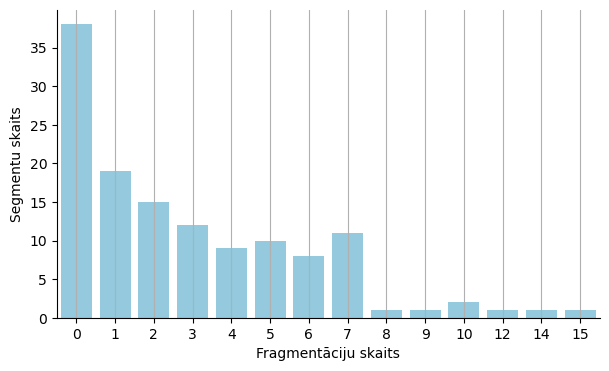

In [344]:
plot_fragmentation_distribution(fragmentation_df_detected)

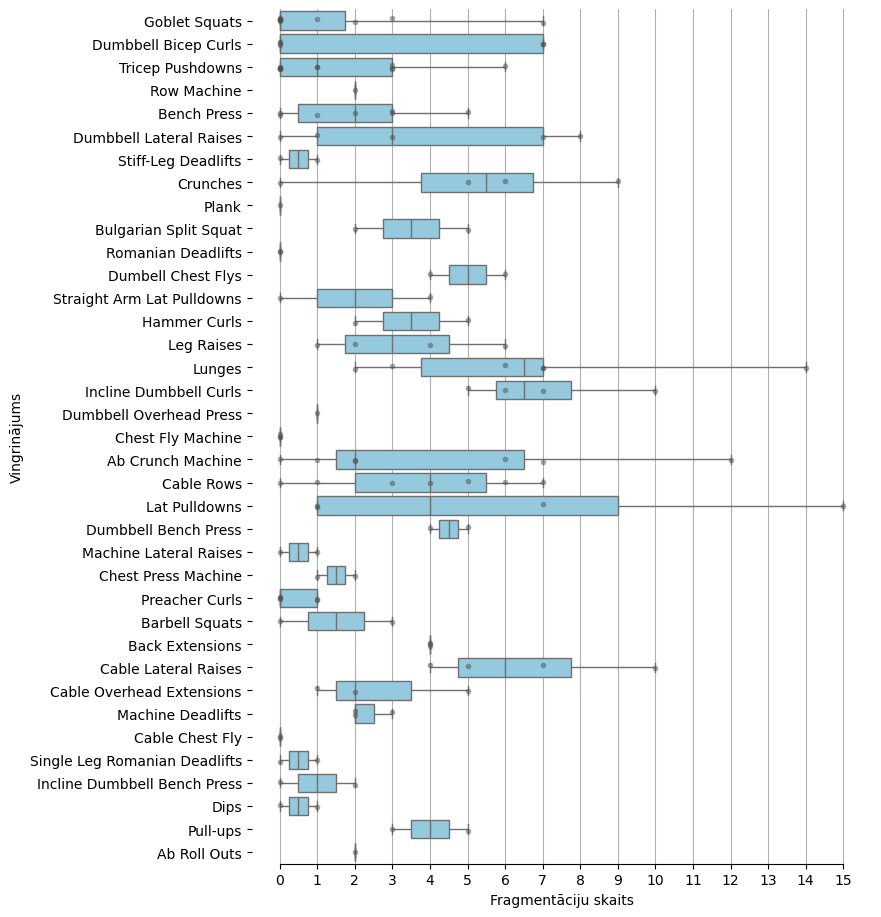

In [345]:
plot_fragmentation_per_exercise(fragmentation_df_detected)

In [346]:
calculate_fragmentation_per_session(fragmentation_df_detected)

,session,Vidējais,Mediānais,Q1,Q3,Maksimālais,Standartnovirze,Fragmentēto segmentu īpatsvars (%)
0,session_1776786984700,2.368421,1.0,1.00,3.00,8,2.241292,42.105263
1,session_1776875240569,4.375000,4.5,2.75,6.00,9,2.473190,81.250000
2,session_1776938763711,3.357143,2.0,1.00,5.50,8,2.734597,64.285714
3,session_1777025558126,6.466667,6.0,3.00,8.00,16,4.627043,80.000000
4,session_1777104300830,2.631579,2.0,2.00,3.00,8,1.640140,78.947368
5,session_1777394359098,4.433333,4.5,2.00,6.00,13,3.070250,76.666667
6,session_1777462103399,3.812500,3.0,1.00,6.25,11,3.081531,68.750000


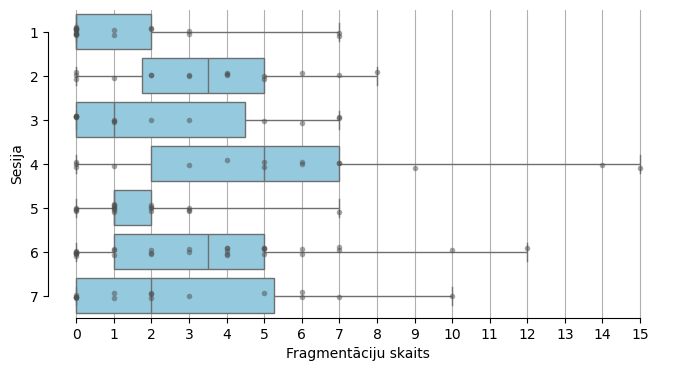

In [347]:
plot_fragmentation_per_session(fragmentation_df_detected)

In [350]:
calculate_fragmentation_per_group(fragmentation_df_detected)

,group,Vidējais,Mediānais,Q1,Q3,Maksimālais
0,Abs,3.823529,2.0,1.0,6.00,12
1,Back,4.000000,4.0,1.5,5.00,15
2,Biceps,3.187500,1.5,0.0,6.25,10
3,Chest,1.900000,1.5,0.0,3.25,6
4,Legs,2.448276,2.0,0.0,3.00,14
5,Shoulders,3.916667,3.5,1.0,7.00,10
6,Triceps,1.625000,1.0,0.0,3.00,6


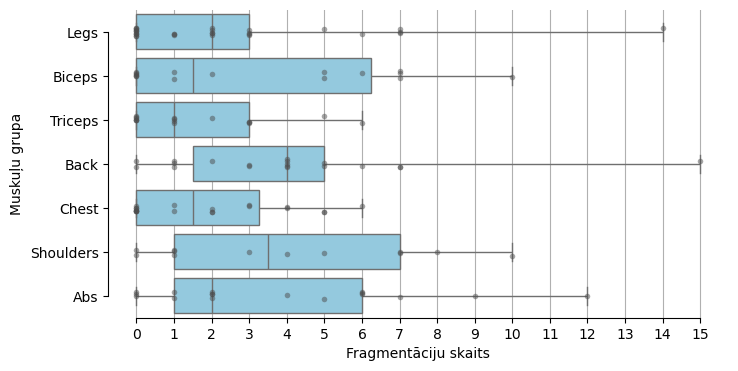

In [348]:
plot_fragmentation_per_group(fragmentation_df_detected)